<a href="https://colab.research.google.com/github/AqsaHerryPrastyo/PCVK/blob/main/Week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt



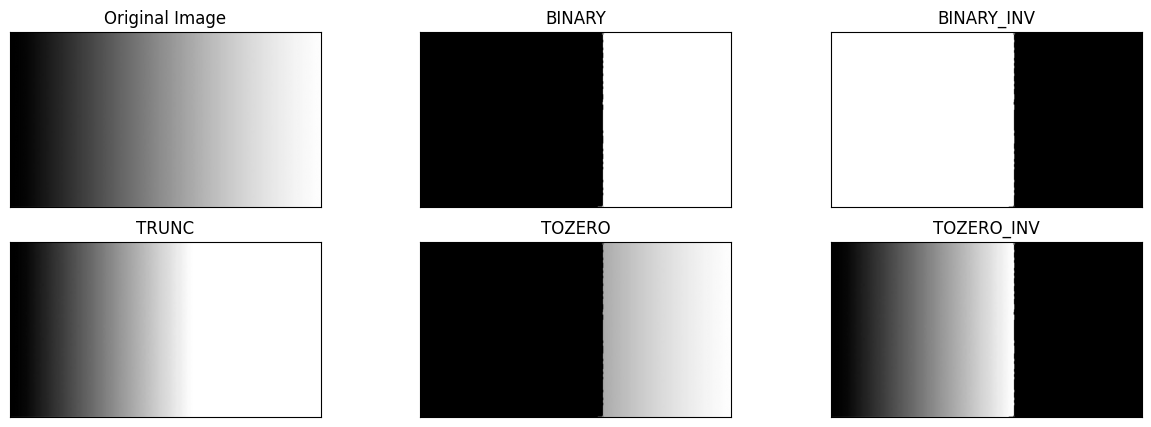

In [9]:
# Ganti path ini sesuai dengan lokasi gambar di Drive Anda
img_path = '/content/drive/MyDrive/Image/gradient.jpg'
img = cv2.imread(img_path, 0) # 0 untuk memuat sebagai grayscale

# Tambahkan pengecekan apakah gambar berhasil dimuat
if img is None:
    print(f"Error: Image not found at {img_path}")
else:
    thresh = 170
    maxval = 255

    # Buat salinan gambar untuk setiap jenis threshold
    thresh_binary = np.zeros_like(img)
    thresh_binary_inv = np.zeros_like(img)
    thresh_trunc = np.zeros_like(img)
    thresh_tozero = np.zeros_like(img)
    thresh_tozero_inv = np.zeros_like(img)

    # Dapatkan tinggi dan lebar gambar
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            pixel_value = img[i, j]

            # 1. Binary Threshold [cite: 61]
            if pixel_value > thresh:
                thresh_binary[i, j] = maxval
            else:
                thresh_binary[i, j] = 0

            # 2. Binary-Inverted Threshold [cite: 67]
            if pixel_value > thresh:
                thresh_binary_inv[i, j] = 0
            else:
                thresh_binary_inv[i, j] = maxval

            # 3. Truncate Threshold [cite: 72]
            if pixel_value > thresh:
                thresh_trunc[i, j] = thresh
            else:
                thresh_trunc[i, j] = pixel_value

            # 4. Threshold To Zero [cite: 76]
            if pixel_value > thresh:
                thresh_tozero[i, j] = pixel_value
            else:
                thresh_tozero[i, j] = 0

            # 5. Threshold To Zero-Inverted [cite: 82]
            if pixel_value > thresh:
                thresh_tozero_inv[i, j] = 0
            else:
                thresh_tozero_inv[i, j] = pixel_value

titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh_binary, thresh_binary_inv, thresh_trunc, thresh_tozero, thresh_tozero_inv]

plt.figure(figsize=(15, 5))
for i in range(len(images)):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.show()

#Otsu's Thresholding Manual

In [10]:
img_path_balloon = '/content/drive/MyDrive/Image/balloon.jpeg'
img_balloon = cv2.imread(img_path_balloon, 0)

In [11]:
# Hitung histogram dan normalisasikan untuk mendapatkan probabilitas (p(i))
hist = cv2.calcHist([img_balloon], [0], None, [256], [0, 256])
total_pixels = img_balloon.shape[0] * img_balloon.shape[1]
hist_normalized = hist.ravel() / total_pixels

In [12]:
max_between_variance = 0
best_thresh = 0

for t in range(256):
    # 1. Pisahkan kelas (Background dan Foreground) berdasarkan threshold t
    w_b = np.sum(hist_normalized[:t]) # Weight Background [cite: 232]
    w_f = np.sum(hist_normalized[t:]) # Weight Foreground [cite: 232]

    if w_b == 0 or w_f == 0:
        continue

    # 2. Hitung Mean untuk tiap kelas [cite: 239, 240]
    # (i * p(i))
    mean_b = np.sum(np.arange(t) * hist_normalized[:t]) / w_b
    mean_f = np.sum(np.arange(t, 256) * hist_normalized[t:]) / w_f

    # 3. Hitung Between-Class Variance [cite: 365]
    between_variance = w_b * w_f * ((mean_b - mean_f) ** 2)

    # 4. Cek apakah ini variance terbesar
    if between_variance > max_between_variance:
        max_between_variance = between_variance
        best_thresh = t

print(f"Otsu's Thresholding (Manual): v = {best_thresh}")

Otsu's Thresholding (Manual): v = 207


In [13]:
# Terapkan Global Thresholding (v=90) seperti contoh
ret_global, thresh_global = cv2.threshold(img_balloon, 90, 255, cv2.THRESH_BINARY)

# Terapkan Otsu's Thresholding manual Anda
ret_otsu, thresh_otsu_manual = cv2.threshold(img_balloon, best_thresh, 255, cv2.THRESH_BINARY)

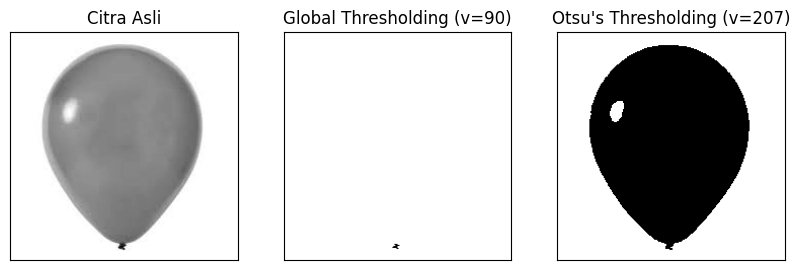

In [14]:
titles = ['Citra Asli', 'Global Thresholding (v=90)', f"Otsu's Thresholding (v={best_thresh})"]
images = [img_balloon, thresh_global, thresh_otsu_manual]

plt.figure(figsize=(10, 5))
for i in range(len(images)):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.show()

# Histogram Masking

In [15]:
img_path_tobacco = '/content/drive/MyDrive/Image/tobacco.jpeg'
img_tobacco = cv2.imread(img_path_tobacco)
img_tobacco_rgb = cv2.cvtColor(img_tobacco, cv2.COLOR_BGR2RGB) # Konversi ke RGB untuk matplotlib

gray_tobacco = cv2.cvtColor(img_tobacco, cv2.COLOR_BGR2GRAY)

# Gunakan Otsu's. Latar belakang gambar 'tobacco.jpg' tampak terang,
# jadi kita mungkin perlu THRESH_BINARY_INV untuk membuat objeknya putih.
ret, mask = cv2.threshold(gray_tobacco, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

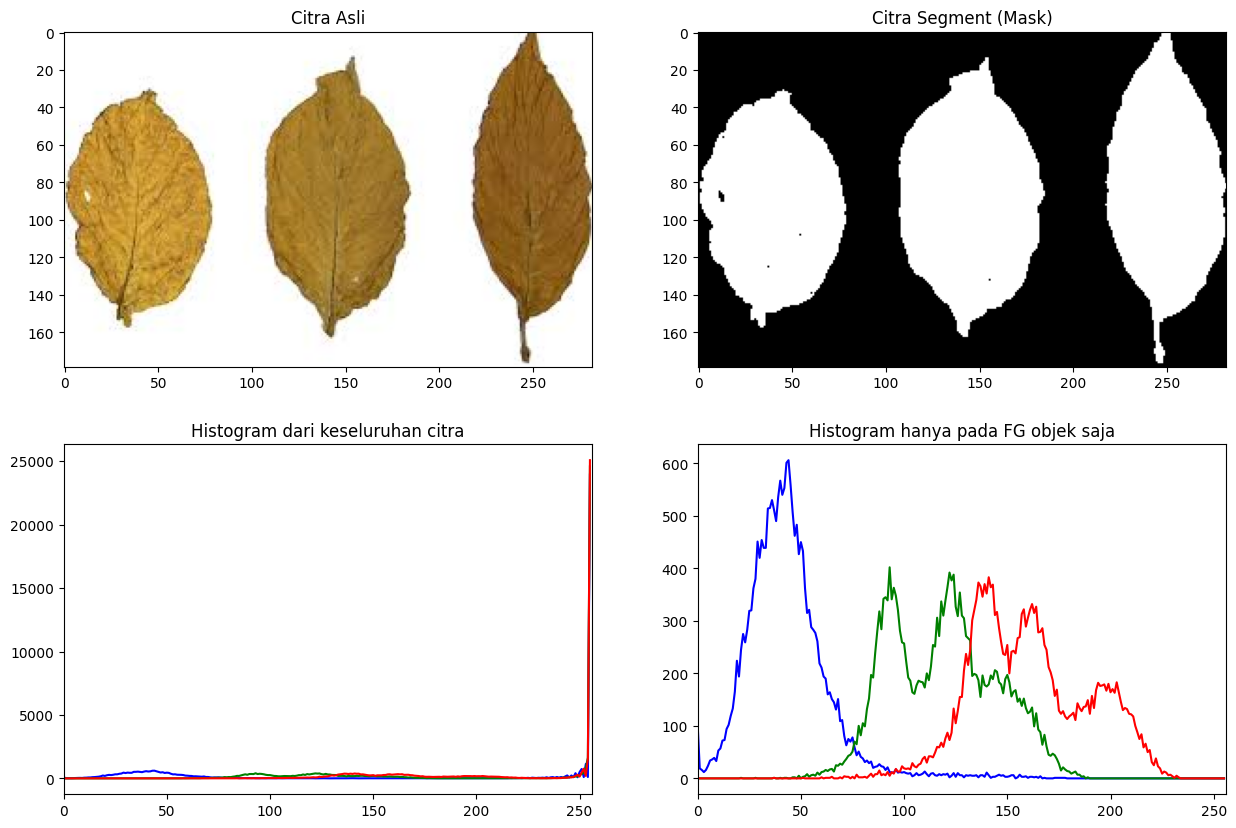

In [17]:
color = ('b', 'g', 'r') # OpenCV BGR, tapi kita load sebagai RGB

# --- Plot 1: Histogram Keseluruhan ---
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
plt.imshow(img_tobacco_rgb)
plt.title('Citra Asli')

plt.subplot(2, 2, 3)
plt.title('Histogram dari keseluruhan citra')
for i, col in enumerate(color):
    # Perhatikan: img_tobacco (BGR) digunakan untuk cv.calcHist
    hist_full = cv2.calcHist([img_tobacco], [i], None, [256], [0, 256])
    plt.plot(hist_full, color=col)
plt.xlim([0, 256])

# --- Plot 2: Histogram Foreground Saja ---
plt.subplot(2, 2, 2)
plt.imshow(mask, 'gray')
plt.title('Citra Segment (Mask)')

plt.subplot(2, 2, 4)
plt.title('Histogram hanya pada FG objek saja')
for i, col in enumerate(color):
    # Gunakan 'mask' yang sudah dibuat
    hist_masked = cv2.calcHist([img_tobacco], [i], mask, [256], [0, 256])
    plt.plot(hist_masked, color=col)
plt.xlim([0, 256])

plt.show()

# Segmentasi Warna K-Means

In [19]:
img_path_peppers = '/content/drive/MyDrive/Image/peppers.jpg'
img_peppers = cv2.imread(img_path_peppers)
img_peppers_rgb = cv2.cvtColor(img_peppers, cv2.COLOR_BGR2RGB)

# Reshape image
pixel_values = img_peppers_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# K-Means
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 4 # Coba 4 cluster
ret, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Konversi centers ke uint8 dan reshape
centers = np.uint8(centers)
segmented_image_data = centers[labels.flatten()]
segmented_image = segmented_image_data.reshape(img_peppers_rgb.shape)

In [20]:
# Cek nilai 'centers' untuk menemukan cluster kuning
# Nilai RGB untuk kuning adalah (Tinggi, Tinggi, Rendah)
print("Nilai rata-rata cluster (RGB):")
print(centers)

# --- Asumsikan setelah dicek, cluster 'kuning' adalah index ke-X ---
# (Ini harus Anda cari tahu secara manual dengan melihat output 'centers')
# Misalnya, jika 'centers' terlihat seperti:
# [[200, 200, 200],  <- cluster 0 (putih)
#  [220, 220, 50],   <- cluster 1 (kuning)
#  [50, 150, 50],    <- cluster 2 (hijau)
#  [180, 40, 40]]    <- cluster 3 (merah)
# Maka cluster_yellow_index = 1

# Anda harus menentukan 'cluster_yellow_index' secara manual
# cluster_yellow_index = 1 # GANTI INI SESUAI HASIL ANDA

# Cara otomatis (tapi mungkin kurang akurat):
yellow_rgb = np.array([255, 255, 0])
distances = np.linalg.norm(centers - yellow_rgb, axis=1)
cluster_yellow_index = np.argmin(distances)
print(f"Cluster yang paling dekat dengan kuning adalah index: {cluster_yellow_index}")

# Buat masked image (seperti contoh di [cite: 523-531])
# Ubah semua piksel yang BUKAN cluster kuning menjadi putih (background)
masked_data = pixel_values.copy()

# Ubah label menjadi 1D
labels_flat = labels.flatten()

# Set semua piksel yang BUKAN cluster kuning ke [255, 255, 255] (putih)
masked_data[labels_flat != cluster_yellow_index] = [255, 255, 255]

# Kembalikan piksel kuning ke warna aslinya (bukan warna centroid)
# Ini akan terlihat lebih baik
masked_data[labels_flat == cluster_yellow_index] = pixel_values[labels_flat == cluster_yellow_index]

# Reshape ke gambar asli
masked_image = masked_data.reshape(img_peppers_rgb.shape)

Nilai rata-rata cluster (RGB):
[[252 250 248]
 [143  42  19]
 [176 131  82]
 [250 206   4]]
Cluster yang paling dekat dengan kuning adalah index: 3


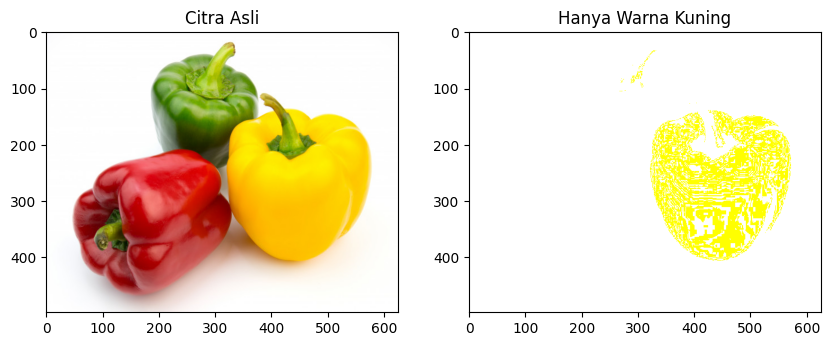

In [21]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_peppers_rgb)
plt.title('Citra Asli')

plt.subplot(1, 2, 2)
plt.imshow(masked_image)
plt.title('Hanya Warna Kuning')
plt.show()

Penentuan k: Sulit menentukan jumlah k (cluster) yang pas. Jika k terlalu kecil, warna yang berbeda (misal kuning dan hijau muda) bisa tergabung. Jika k terlalu besar, satu warna (kuning) bisa terpecah jadi beberapa cluster (kuning muda, kuning tua) karena bayangan.

Pencahayaan: K-Means sangat sensitif terhadap pencahayaan. Pantulan cahaya (highlight) pada paprika kuning mungkin warnanya sangat dekat dengan putih, sehingga bisa dikelompokkan sebagai background (putih).

Kedekatan Warna: K-Means mengelompokkan berdasarkan jarak warna di ruang RGB. Bagian tangkai paprika kuning mungkin warnanya lebih dekat ke hijau daripada kuning, sehingga bisa salah dikelompokkan ke cluster hijau.

# Thresholding Terbaik 'crossword.jpg'

In [23]:
img_path_crossword = '/content/drive/MyDrive/Image/crossword.jpg'
img_crossword = cv2.imread(img_path_crossword, 0) # Muat grayscale

# Tambahkan pengecekan apakah gambar berhasil dimuat
if img_crossword is None:
    print(f"Error: Image not found at {img_path_crossword}")
else:
    # Terapkan Global Threshold (sebagai perbandingan)
    ret, thresh_global_cw = cv2.threshold(img_crossword, 127, 255, cv2.THRESH_BINARY)

    # Terapkan Otsu's (sebagai perbandingan)
    ret, thresh_otsu_cw = cv2.threshold(img_crossword, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Terapkan Adaptive Threshold (Hasil Terbaik)
    # Anda bisa coba ganti-ganti 'blockSize' (harus ganjil) dan 'C'
    blockSize = 11
    C = 2

    thresh_adaptive_mean = cv2.adaptiveThreshold(img_crossword, 255,
                                               cv2.ADAPTIVE_THRESH_MEAN_C,
                                               cv2.THRESH_BINARY, blockSize, C)

    thresh_adaptive_gaussian = cv2.adaptiveThreshold(img_crossword, 255,
                                                   cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                                   cv2.THRESH_BINARY, blockSize, C)

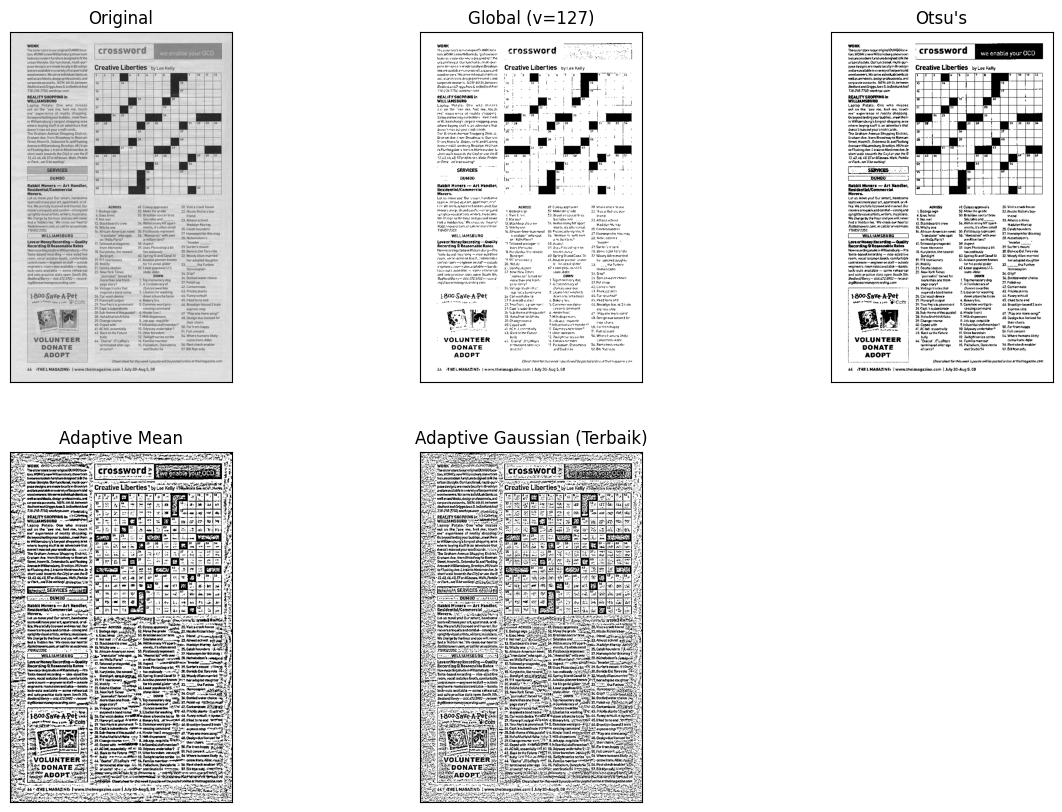

In [24]:
titles = ['Original', 'Global (v=127)', "Otsu's", 'Adaptive Mean', 'Adaptive Gaussian (Terbaik)']
images = [img_crossword, thresh_global_cw, thresh_otsu_cw, thresh_adaptive_mean, thresh_adaptive_gaussian]

plt.figure(figsize=(15, 10))
for i in range(len(images)):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.show()